# Notebook 03 — Modelos Baseline y ARIMA

Este notebook implementa los modelos de referencia (baseline) y el modelo
ARIMA para la predicción de la huella de carbono operacional del sistema
eléctrico español con resolución de 15 minutos.

**Punto de partida:** el modelo más simple posible — copiar el valor
de la misma hora del día anterior. A partir de ahí se introduce ARIMA
para intentar mejorar esa referencia.

**Horizontes de predicción:** 48h (192 pasos) y 72h (288 pasos).

**Evaluación:** walk-forward con 12 fits distribuidos por 2024,
misma configuración que el resto de modelos para comparación justa.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

plt.style.use("seaborn-v0_8")
%matplotlib inline

BASE_DIR    = Path("/home/ubuntu/TFM/notebooks")
DATA_DIR    = BASE_DIR / "data_processed"
RESULTS_DIR = Path("/home/ubuntu/TFM/results")
RESULTS_DIR.mkdir(exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

DATA_DIR: /home/ubuntu/TFM/notebooks/data_processed
RESULTS_DIR: /home/ubuntu/TFM/results


## 1. Carga de datos

Se cargan los parquets generados en el notebook 01, manteniendo
la misma división temporal que el resto de modelos:
- Train: 2022–2023
- Validación: 2024
- Test: 2025

In [2]:
y_train = pd.read_parquet(DATA_DIR / "train_2022_2023.parquet")["y"].astype(float)
y_val   = pd.read_parquet(DATA_DIR / "val_2024.parquet")["y"].astype(float)
y_test  = pd.read_parquet(DATA_DIR / "test_2025.parquet")["y"].astype(float)

y_train.index = pd.to_datetime(y_train.index)
y_val.index   = pd.to_datetime(y_val.index)
y_test.index  = pd.to_datetime(y_test.index)

print("Train:", y_train.shape, "|", y_train.index.min(), "->", y_train.index.max())
print("Val:  ", y_val.shape,   "|", y_val.index.min(),   "->", y_val.index.max())
print("Test: ", y_test.shape,  "|", y_test.index.min(),  "->", y_test.index.max())

Train: (70080,) | 2022-01-01 00:00:00+00:00 -> 2023-12-31 23:45:00+00:00
Val:   (35136,) | 2024-01-01 00:00:00+00:00 -> 2024-12-31 23:45:00+00:00
Test:  (35040,) | 2025-01-01 00:00:00+00:00 -> 2025-12-31 23:45:00+00:00


## 2. Configuración temporal y métricas

La serie tiene resolución de 15 minutos, por lo que:
- 1 hora = 4 pasos
- 24 horas = 96 pasos (periodo estacional diario)
- 48 horas = 192 pasos
- 72 horas = 288 pasos

In [3]:
FREQ_MIN        = 15
STEPS_PER_HOUR  = 60 // FREQ_MIN
SEASONAL_PERIOD = 24 * STEPS_PER_HOUR  # 96

HORIZONS = {
    "48h": 48 * STEPS_PER_HOUR,  # 192 pasos
    "72h": 72 * STEPS_PER_HOUR,  # 288 pasos
}

@dataclass
class WFConfig:
    step: int
    min_history: int
    max_fits: int

def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"MAE": mae, "RMSE": rmse}

print("Periodo estacional:", SEASONAL_PERIOD)
print("Horizontes:", HORIZONS)

Periodo estacional: 96
Horizontes: {'48h': 192, '72h': 288}


In [4]:
# Configuración para modelos naive — muchos puntos de evaluación
cfg_naive = WFConfig(
    step=SEASONAL_PERIOD,            # evaluar cada día
    min_history=30 * SEASONAL_PERIOD,
    max_fits=300                     # cubre todo 2024
)

# Configuración para ARIMA — menos fits por coste computacional
cfg_arima = WFConfig(
    step=28 * SEASONAL_PERIOD,       # reentrenamiento mensual
    min_history=30 * SEASONAL_PERIOD,
    max_fits=12
)

def walk_forward_splits(series, horizons, cfg):
    n     = len(series)
    max_h = max(horizons.values())
    points = list(range(cfg.min_history, n - max_h, cfg.step))
    points = points[:cfg.max_fits]
    for t0 in points:
        train_part = series.iloc[:t0]
        tests = {k: series.iloc[t0:t0 + h] for k, h in horizons.items()}
        yield train_part, tests

def summarize(df, model_name):
    out = (
        df.groupby("horizon")[["MAE", "RMSE"]]
        .mean()
        .reset_index()
    )
    out.insert(0, "model", model_name)
    return out

def evaluate_model(y_train, y_val, horizons, cfg, forecaster, verbose=False):
    rows        = []
    preds_store = []
    y_full  = pd.concat([y_train, y_val]).sort_index()
    n_train = len(y_train)
    splits  = list(walk_forward_splits(y_val, horizons, cfg))
    total   = len(splits)

    for i, (train_part, tests) in enumerate(splits, 1):
        if verbose:
            print(f"Fit {i}/{total}")
        cutoff_idx   = n_train + len(train_part)
        cutoff_time  = y_full.index[cutoff_idx - 1]
        train_window = y_full.iloc[:cutoff_idx]

        fit_preds = {"cutoff_time": cutoff_time, "train_window": train_window}
        for name, test in tests.items():
            pred = forecaster(train_window, len(test))
            m    = compute_metrics(test.values, pred)
            rows.append({"horizon": name, "MAE": m["MAE"], "RMSE": m["RMSE"]})
            fit_preds[name] = {"pred": pred, "test": test}
        preds_store.append(fit_preds)

    return pd.DataFrame(rows), preds_store

print("cfg_naive: step=1 día, max_fits=300")
print("cfg_arima: step=28 días, max_fits=12")

cfg_naive: step=1 día, max_fits=300
cfg_arima: step=28 días, max_fits=12


## 4. Modelos Baseline (Naive)

Los modelos naive sirven como referencia mínima — cualquier modelo
más complejo debe superarlos para justificar su uso.

**Naive_last:** predice el último valor observado para todo el horizonte.

**Naive_seasonal:** retrocede exactamente H pasos atrás y copia ese
segmento como predicción:
- Para 48h -> copia los 2 días anteriores
- Para 72h -> copia los 3 días anteriores

In [5]:
def forecast_naive_last(train, h):
    return np.repeat(train.values[-1], h)

def forecast_naive_seasonal(train, h, season=96):
    if len(train) < season:
        return forecast_naive_last(train, h)
    pattern = train.values[-season:]
    reps = int(np.ceil(h / season))
    return np.tile(pattern, reps)[:h]

print("Naive_last: predice el último valor observado")
print("Naive_seasonal: copia el patrón de hace H pasos")

Naive_last: predice el último valor observado
Naive_seasonal: copia el patrón de hace H pasos


## 5. Evaluación Naive

In [6]:
print("Evaluando Naive_last...")
naive_last_val, _ = evaluate_model(
    y_train, y_val, HORIZONS, cfg_naive,
    forecast_naive_last
)

print("Evaluando Naive_seasonal...")
naive_seas_val, preds_naive = evaluate_model(
    y_train, y_val, HORIZONS, cfg_naive,
    lambda tr, h: forecast_naive_seasonal(tr, h)
)

naive_summary = pd.concat([
    summarize(naive_last_val, "Naive_last"),
    summarize(naive_seas_val, "Naive_seasonal")
])

naive_summary.to_csv(RESULTS_DIR / "naive_summary.csv", index=False)
print(naive_summary)

Evaluando Naive_last...
Evaluando Naive_seasonal...
            model horizon        MAE       RMSE
0      Naive_last     48h  27.914413  33.983638
1      Naive_last     72h  29.777175  35.970936
0  Naive_seasonal     48h  18.302118  22.741647
1  Naive_seasonal     72h  19.662055  24.616774


## 6. Visualización Naive_seasonal

El Naive_seasonal es el baseline principal — cualquier modelo
más complejo debe superar este resultado para justificar su uso.
Se muestran 4 puntos representativos distribuidos por 2024.

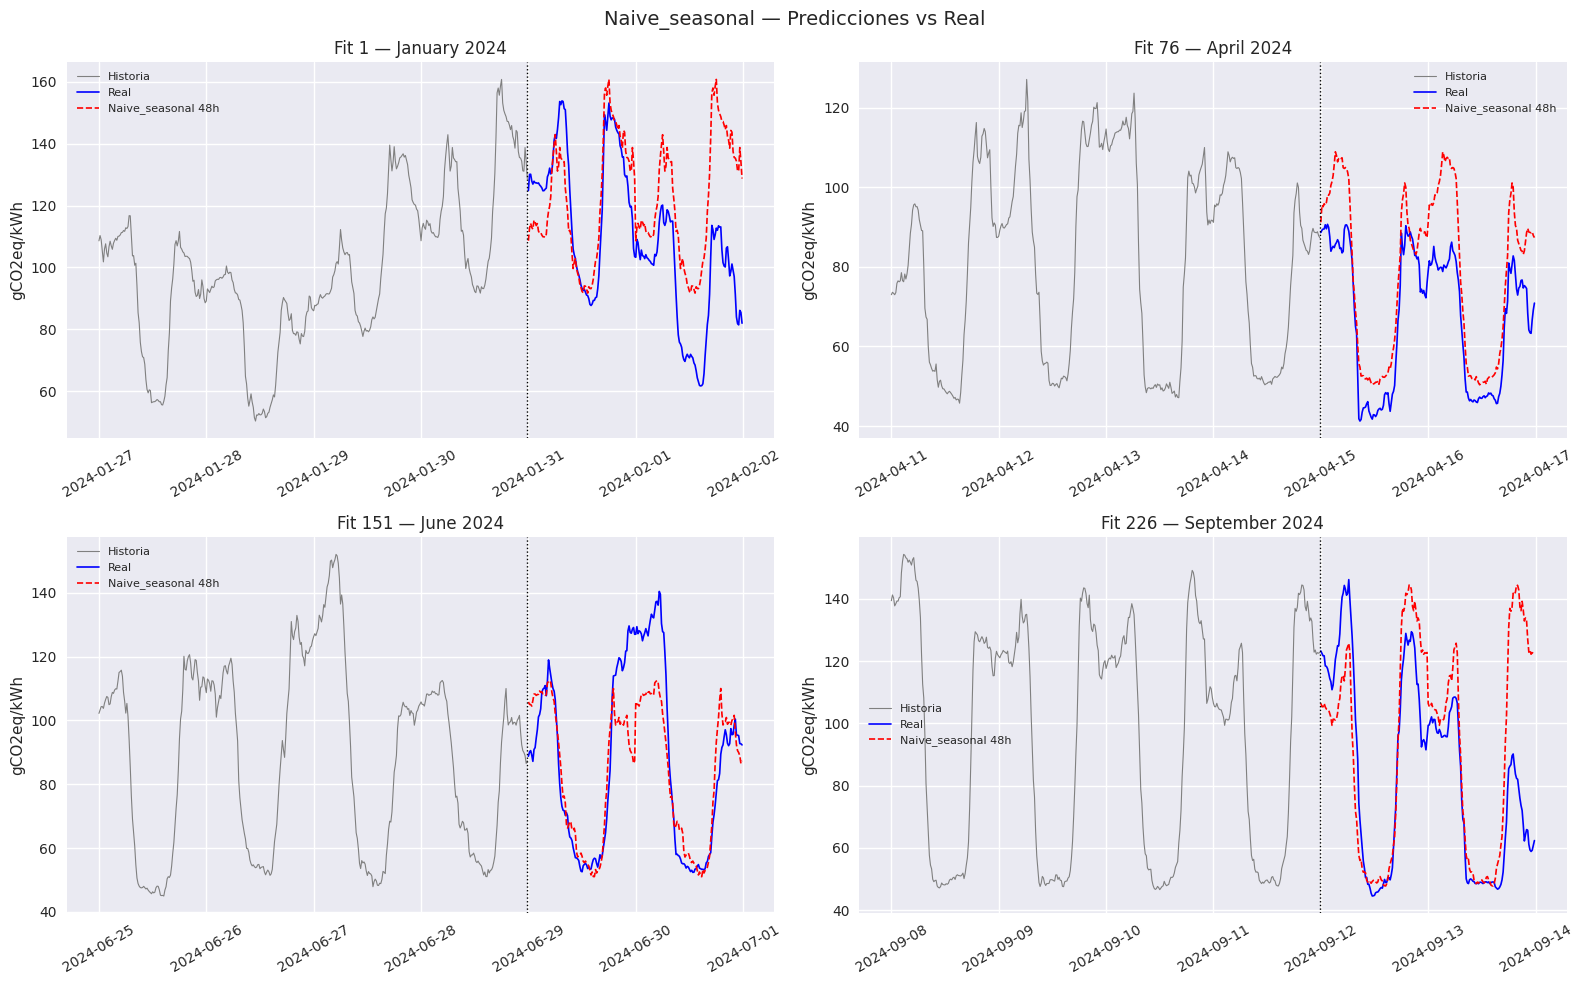

In [7]:
# Cogemos 4 puntos representativos de los 300 fits
splits_naive = list(walk_forward_splits(y_val, HORIZONS, cfg_naive))
indices = [0, 75, 150, 225]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Naive_seasonal — Predicciones vs Real", fontsize=14)

y_full = pd.concat([y_train, y_val]).sort_index()

for idx, split_idx in enumerate(indices):
    ax = axes[idx // 2][idx % 2]
    fit         = preds_naive[split_idx]
    cutoff_time = fit["cutoff_time"]
    train_w     = fit["train_window"]
    test_48     = fit["48h"]["test"]
    pred_48     = fit["48h"]["pred"]

    history = train_w.iloc[-4 * SEASONAL_PERIOD:]
    ax.plot(history.index, history.values,
            color="gray", label="Historia", linewidth=0.8)
    ax.plot(test_48.index, test_48.values,
            color="blue", label="Real", linewidth=1.2)
    ax.plot(test_48.index, pred_48,
            color="red", linestyle="--", label="Naive_seasonal 48h", linewidth=1.2)
    ax.axvline(x=cutoff_time, color="black", linestyle=":", linewidth=1.0)
    ax.set_title(f"Fit {split_idx+1} — {cutoff_time.strftime('%B %Y')}")
    ax.set_ylabel("gCO2eq/kWh")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("/home/ubuntu/TFM/figures/naive_predicciones.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Selección del orden ARIMA — Metodología Box-Jenkins

La metodología Box-Jenkins define un proceso sistemático para
identificar, estimar y validar modelos ARIMA:

1. **Identificación**: análisis de ACF y PACF para determinar p, d, q
   - PACF corta en lag p -> componente AR(p)
   - ACF corta en lag q -> componente MA(q)
   - Número de diferenciaciones necesarias para estacionariedad -> d

2. **Estimación**: ajuste del modelo por máxima verosimilitud

3. **Validación**: análisis de residuos — deben comportarse como ruido blanco

En este notebook se automatiza la fase de identificación con
auto_arima, que implementa la búsqueda stepwise minimizando el AIC.
Esto es equivalente al proceso manual Box-Jenkins pero de forma
sistemática y reproducible.

In [9]:
from pmdarima import auto_arima

# Usar últimos 30 días de train para seleccionar orden
sample = y_train.iloc[-30 * SEASONAL_PERIOD:]

print("Buscando orden óptimo con auto_arima...")
auto_model = auto_arima(
    sample.values,
    start_p=0, max_p=6,
    start_q=0, max_q=3,
    d=None,              # auto-detectar diferenciación
    seasonal=False,      # sin componente estacional 
    information_criterion="aic",
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    verbose=False
)

arima_order = auto_model.order
print("Orden óptimo encontrado:", arima_order)
print("AIC:", round(auto_model.aic(), 2))
print(auto_model.summary())

Buscando orden óptimo con auto_arima...
Orden óptimo encontrado: (5, 1, 0)
AIC: 13077.56
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2880
Model:               SARIMAX(5, 1, 0)   Log Likelihood               -6532.780
Date:                Wed, 11 Mar 2026   AIC                          13077.561
Time:                        08:46:47   BIC                          13113.352
Sample:                             0   HQIC                         13090.462
                               - 2880                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5316      0.012     43.839      0.000       0.508       0.555
ar.L2         -0.0843      0.016     -5.11

## 8. Interpretación del orden seleccionado

auto_arima confirma **ARIMA(5,1,0)** como orden óptimo:

- **d=1**: la serie necesita una diferenciación para ser estacionaria
- **p=5**: el valor actual depende de los 5 rezagos anteriores
- **q=0**: no se necesitan términos de media móvil

**Coeficientes AR:**
- ar.L1 (0.53): dependencia positiva fuerte con el instante anterior
- ar.L4 (0.22): dependencia positiva con hace 1 hora (4 pasos × 15min)
- ar.L2, ar.L5: dependencias negativas — efecto corrector

Todos los coeficientes son estadísticamente significativos (p<0.001).

**Diagnóstico de residuos:**
- Ljung-Box p=0.98 -> residuos no autocorrelacionados 
- Jarque-Bera p=0.00 -> residuos no normales (curtosis=6.22)
- La no normalidad indica presencia de valores atípicos en la serie,
  lo cual es esperable en datos de huella de carbono con eventos
  extremos del mix energético.

## 9. Evaluación ARIMA con walk-forward

Se evalúa ARIMA(5,1,0) con 12 fits distribuidos por 2024.
En cada fit el modelo se reentrena con todo el histórico disponible
hasta ese momento — ventana expansiva.

In [10]:
print("Evaluando ARIMA(5,1,0)...")
arima_val, preds_arima = evaluate_model(
    y_train, y_val, HORIZONS, cfg_arima,
    lambda tr, h: forecast_arima(tr, h, arima_order),
    verbose=True
)

arima_summary = summarize(arima_val, "ARIMA(5,1,0)")
arima_summary.to_csv(RESULTS_DIR / "arima_summary.csv", index=False)
print(arima_summary)

Evaluando ARIMA(5,1,0)...
Fit 1/12
Fit 2/12
Fit 3/12
Fit 4/12
Fit 5/12
Fit 6/12
Fit 7/12
Fit 8/12
Fit 9/12
Fit 10/12
Fit 11/12
Fit 12/12
          model horizon        MAE       RMSE
0  ARIMA(5,1,0)     48h  27.155052  33.796257
1  ARIMA(5,1,0)     72h  28.060853  34.877387


## 10. Visualización ARIMA

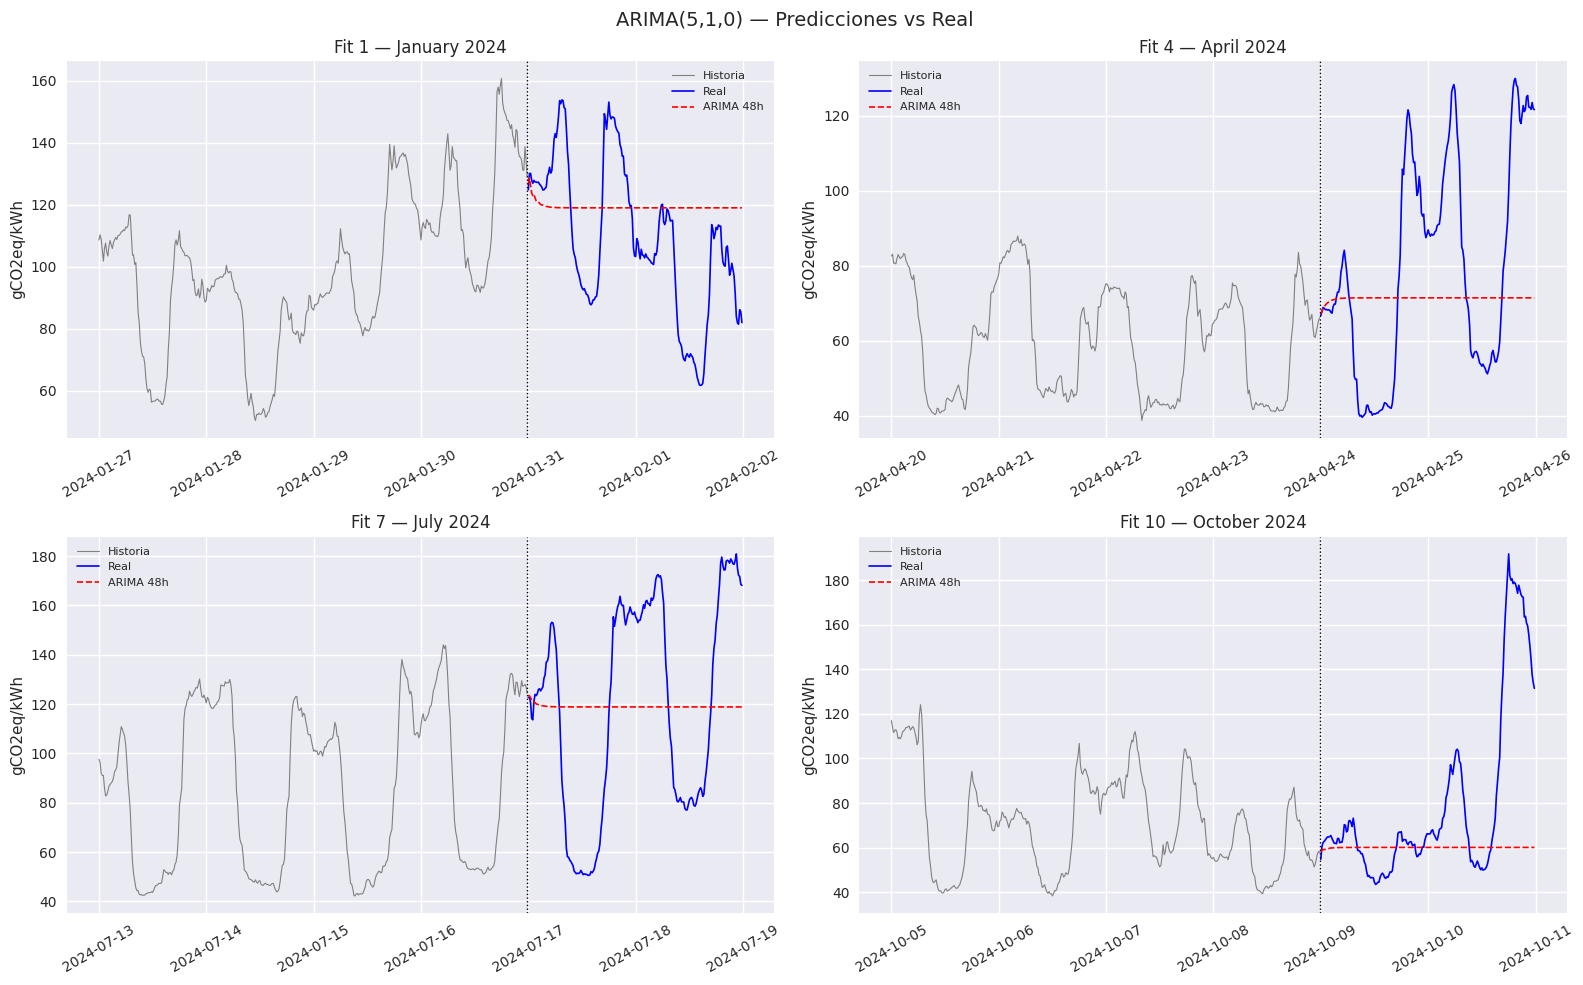

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("ARIMA(5,1,0) — Predicciones vs Real", fontsize=14)

for idx, split_idx in enumerate([0, 3, 6, 9]):
    ax = axes[idx // 2][idx % 2]
    fit         = preds_arima[split_idx]
    cutoff_time = fit["cutoff_time"]
    train_w     = fit["train_window"]
    test_48     = fit["48h"]["test"]
    pred_48     = fit["48h"]["pred"]

    history = train_w.iloc[-4 * SEASONAL_PERIOD:]
    ax.plot(history.index, history.values,
            color="gray", label="Historia", linewidth=0.8)
    ax.plot(test_48.index, test_48.values,
            color="blue", label="Real", linewidth=1.2)
    ax.plot(test_48.index, pred_48,
            color="red", linestyle="--", label="ARIMA 48h", linewidth=1.2)
    ax.axvline(x=cutoff_time, color="black", linestyle=":", linewidth=1.0)
    ax.set_title(f"Fit {split_idx+1} — {cutoff_time.strftime('%B %Y')}")
    ax.set_ylabel("gCO2eq/kWh")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("/home/ubuntu/TFM/figures/arima_predicciones.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Comparación Naive vs ARIMA

In [12]:
compare = pd.concat([naive_summary, arima_summary], ignore_index=True)
compare_pivot = compare.pivot_table(
    index="model",
    columns="horizon",
    values=["MAE", "RMSE"]
).round(3)

print(compare_pivot)
compare.to_csv(RESULTS_DIR / "naive_arima_summary.csv", index=False)

                   MAE            RMSE        
horizon            48h     72h     48h     72h
model                                         
ARIMA(5,1,0)    27.155  28.061  33.796  34.877
Naive_last      27.914  29.777  33.984  35.971
Naive_seasonal  18.302  19.662  22.742  24.617


In [13]:
def build_results_row(summary_df):
    """Convierte un summarize() en una fila con MAE y RMSE por horizonte."""
    row = {"model": summary_df["model"].iloc[0]}
    for _, r in summary_df.iterrows():
        row[f"MAE_{r['horizon']}"]  = round(r["MAE"], 3)
        row[f"RMSE_{r['horizon']}"] = round(r["RMSE"], 3)
    return row

resultados = pd.DataFrame([
    build_results_row(summarize(naive_last_val, "Naive_last")),
    build_results_row(summarize(naive_seas_val, "Naive_seasonal")),
    build_results_row(arima_summary),
]).set_index("model")

print(resultados)
resultados.to_csv(RESULTS_DIR / "comparacion_naive_arima.csv")

                MAE_48h  RMSE_48h  MAE_72h  RMSE_72h
model                                               
Naive_last       27.914    33.984   29.777    35.971
Naive_seasonal   18.302    22.742   19.662    24.617
ARIMA(5,1,0)     27.155    33.796   28.061    34.877


## Interpretación de resultados — Naive y ARIMA

### Naive_last
El modelo de persistencia simple obtiene un MAE de 27.91 gCO2eq/kWh
a 48h y 29.78 gCO2eq/kWh a 72h. Es el peor modelo de los evaluados,
lo que confirma que la serie tiene estructura temporal explotable
— el último valor observado no es una buena estimación del futuro.

### Naive_seasonal
El modelo estacional obtiene un MAE de 18.30 gCO2eq/kWh a 48h y
19.66 gCO2eq/kWh a 72h, mejorando un 34% sobre Naive_last.
Este resultado confirma que la serie tiene un patrón diario muy
marcado — copiar el mismo periodo del día anterior es una estrategia
competitiva que cualquier modelo más complejo debe superar.

Este modelo se establece como **baseline principal** del TFM.

### ARIMA(5,1,0)
ARIMA obtiene un MAE de 27.15 gCO2eq/kWh a 48h — prácticamente
igual que Naive_last y muy por encima del Naive_seasonal.

La causa es estructural: ARIMA con p=5 solo recuerda los últimos
75 minutos de historia. Para horizontes de 48h y 72h la predicción
colapsa a la media de la serie diferenciada, perdiendo completamente
el patrón diario que el Naive_seasonal sí captura.

Este resultado motiva el uso de modelos con mayor capacidad de
memoria y componente estacional explícita — SARIMA, AutoReg y LSTM.